In [ ]:
# Install required libraries
!pip install scikit-learn pandas numpy matplotlib seaborn tensorflow -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# Neural Network
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

In [ ]:
df = pd.read_csv('/content/Career_Switch_Prediction_Dataset - Career_Switch_Prediction_Dataset.csv')
print("Dataset loaded successfully!")
df.head(10)

Dataset loaded successfully!


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,will_change_career
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,0,83,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,0,52,1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0
5,21651,city_176,0.764,NaN,Has relevent experience,Part time course,Graduate,STEM,11,NaN,NaN,1,24,1
6,28806,city_160,0.920,Male,Has relevent experience,no_enrollment,High School,NaN,5,50-99,Funded Startup,1,24,0
7,402,city_46,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,<10,Pvt Ltd,>4,18,1
8,27107,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7,50-99,Pvt Ltd,1,46,1
9,699,city_103,0.920,NaN,Has relevent experience,no_enrollment,Graduate,STEM,17,10000+,Pvt Ltd,>4,123,0


In [ ]:
print("=" * 55)
print(f"Total Data Points (Rows) : {df.shape[0]}")
print(f"Total Features (Columns) : {df.shape[1]}")
print(f"Input Features           : {df.shape[1] - 1}")
print(f"Target Feature           : will_change_career")
print("=" * 55)
print()
print("Column Data Types:")
print(df.dtypes)

Total Data Points (Rows) : 5000
Total Features (Columns) : 14
Input Features           : 13
Target Feature           : will_change_career

Column Data Types:
enrollee_id                 int64
city                       object
city_development_index    float64
gender                     object
relevent_experience        object
enrolled_university        object
education_level            object
major_discipline           object
experience                 object
company_size               object
company_type               object
last_new_job               object
training_hours              int64
will_change_career          int64
dtype: object


In [ ]:
print("Quantitative (Numerical) Features:")
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols_input = [c for c in num_cols if c not in ['enrollee_id', 'will_change_career']]
print(num_cols_input)

print()
print("Categorical Features:")
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(cat_cols)

print()
print("Statistical Summary of Numerical Features:")
df[num_cols_input + ['training_hours']].describe()

Quantitative (Numerical) Features:
['city_development_index', 'training_hours']

Categorical Features:
['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']

Statistical Summary of Numerical Features:


,city_development_index,training_hours,training_hours
count,5000.000000,5000.000000,5000.000000
mean,0.829410,65.027200,65.027200
std,0.122429,59.946693,59.946693
min,0.448000,1.000000,1.000000
25%,0.743000,23.000000,23.000000
50%,0.903000,47.000000,47.000000
75%,0.920000,88.000000,88.000000
max,0.949000,336.000000,336.000000


Target Class Distribution:
  Class 0 (Will NOT change career): 3738 (74.8%)
  Class 1 (Will change career)    : 1262 (25.2%)


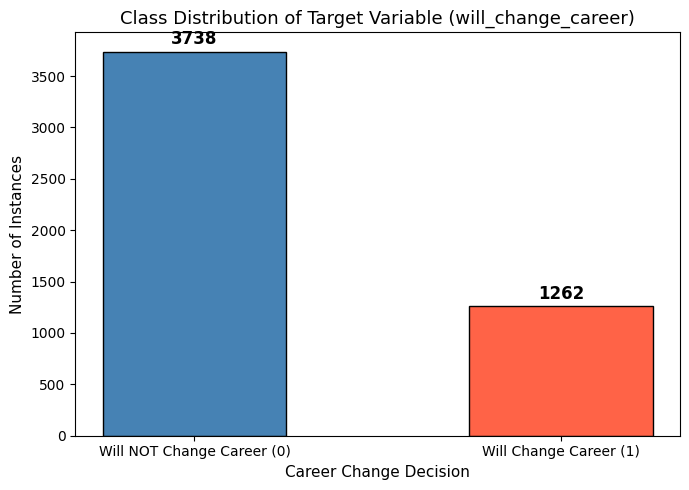


Observation: The dataset is IMBALANCED. Class 0 has ~3x more instances than Class 1.
We will use Stratified splitting to maintain this ratio in train/test sets.


In [ ]:
target_counts = df['will_change_career'].value_counts()
print("Target Class Distribution:")
print(f"  Class 0 (Will NOT change career): {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)")
print(f"  Class 1 (Will change career)    : {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)")

# Bar Chart
plt.figure(figsize=(7, 5))
bars = plt.bar(
    ['Will NOT Change Career (0)', 'Will Change Career (1)'],
    target_counts.values,
    color=['steelblue', 'tomato'],
    edgecolor='black',
    width=0.5
)
for bar, val in zip(bars, target_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.title('Class Distribution of Target Variable (will_change_career)', fontsize=13)
plt.xlabel('Career Change Decision', fontsize=11)
plt.ylabel('Number of Instances', fontsize=11)
plt.tight_layout()
plt.show()

print()
print("Observation: The dataset is IMBALANCED. Class 0 has ~3x more instances than Class 1.")
print("We will use Stratified splitting to maintain this ratio in train/test sets.")

### 2.3 Exploratory Data Analysis (EDA)

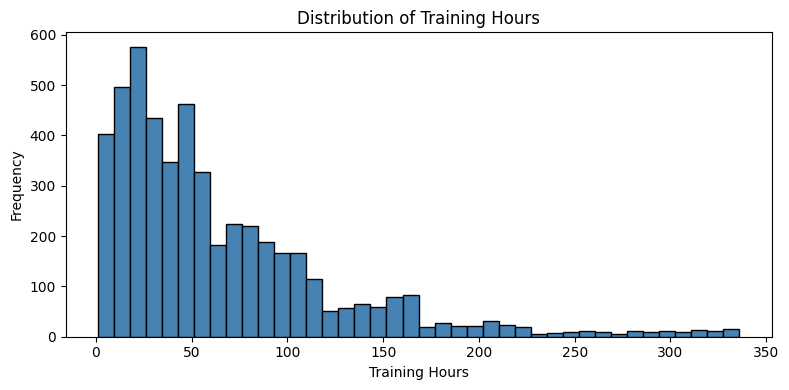

In [ ]:
# --- Distribution of Training Hours ---
plt.figure(figsize=(8, 4))
plt.hist(df['training_hours'], bins=40, color='steelblue', edgecolor='black')
plt.title('Distribution of Training Hours')
plt.xlabel('Training Hours')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

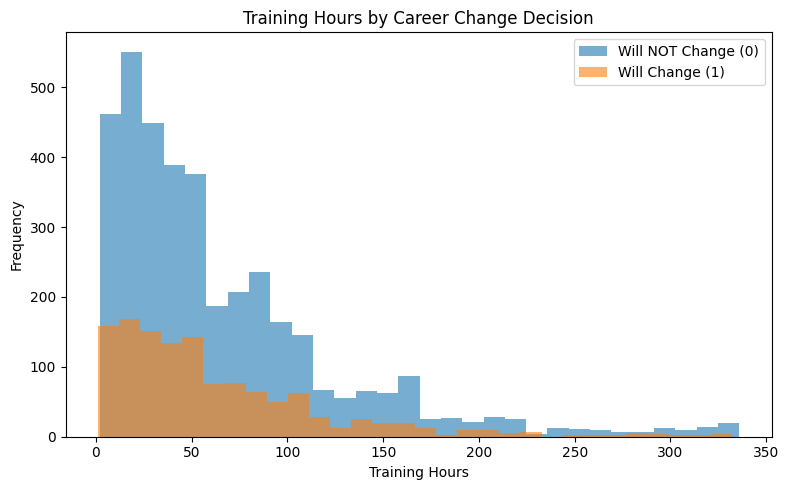

In [ ]:
# --- Training Hours vs Career Change ---
plt.figure(figsize=(8, 5))
df.groupby('will_change_career')['training_hours'].plot(kind='hist', bins=30, alpha=0.6, legend=True)
plt.title('Training Hours by Career Change Decision')
plt.xlabel('Training Hours')
plt.ylabel('Frequency')
plt.legend(['Will NOT Change (0)', 'Will Change (1)'])
plt.tight_layout()
plt.show()

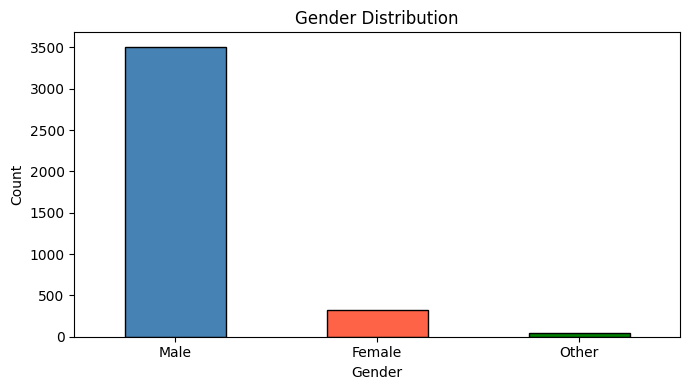

In [ ]:
# --- Gender Distribution ---
plt.figure(figsize=(7, 4))
df['gender'].value_counts().plot(kind='bar', color=['steelblue','tomato','green'], edgecolor='black')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 900x500 with 0 Axes>

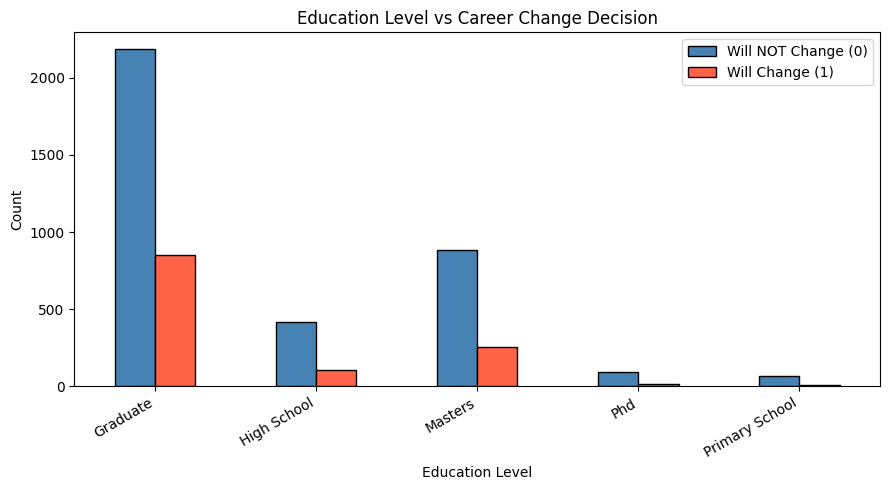

In [ ]:
# --- Education Level vs Career Change ---
plt.figure(figsize=(9, 5))
edu_career = df.groupby(['education_level', 'will_change_career']).size().unstack(fill_value=0)
edu_career.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black', figsize=(9, 5))
plt.title('Education Level vs Career Change Decision')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.legend(['Will NOT Change (0)', 'Will Change (1)'])
plt.tight_layout()
plt.show()

<Figure size 700x400 with 0 Axes>

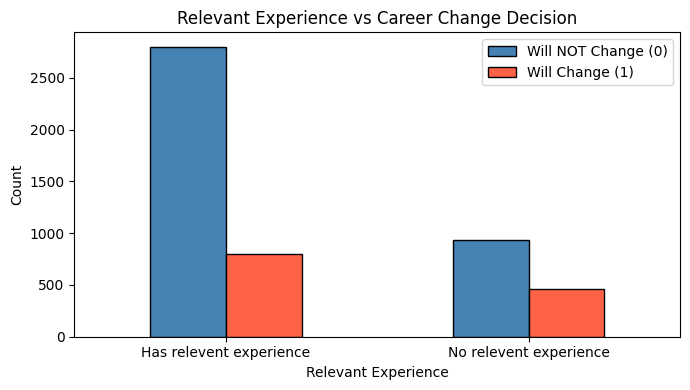

In [ ]:
# --- Relevant Experience vs Career Change ---
plt.figure(figsize=(7, 4))
rel_career = df.groupby(['relevent_experience', 'will_change_career']).size().unstack(fill_value=0)
rel_career.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black', figsize=(7, 4))
plt.title('Relevant Experience vs Career Change Decision')
plt.xlabel('Relevant Experience')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Will NOT Change (0)', 'Will Change (1)'])
plt.tight_layout()
plt.show()

<Figure size 900x500 with 0 Axes>

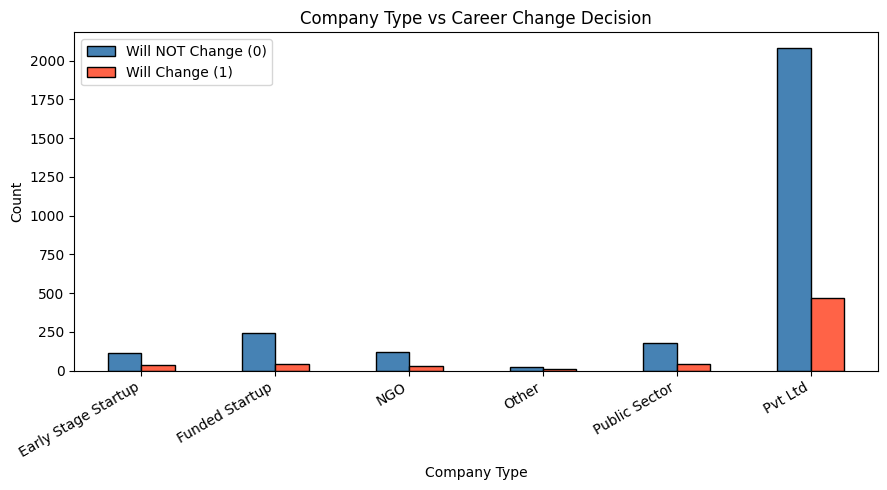

In [ ]:
# --- Company Type vs Career Change ---
plt.figure(figsize=(9, 5))
comp_career = df.groupby(['company_type', 'will_change_career']).size().unstack(fill_value=0)
comp_career.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black', figsize=(9, 5))
plt.title('Company Type vs Career Change Decision')
plt.xlabel('Company Type')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.legend(['Will NOT Change (0)', 'Will Change (1)'])
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

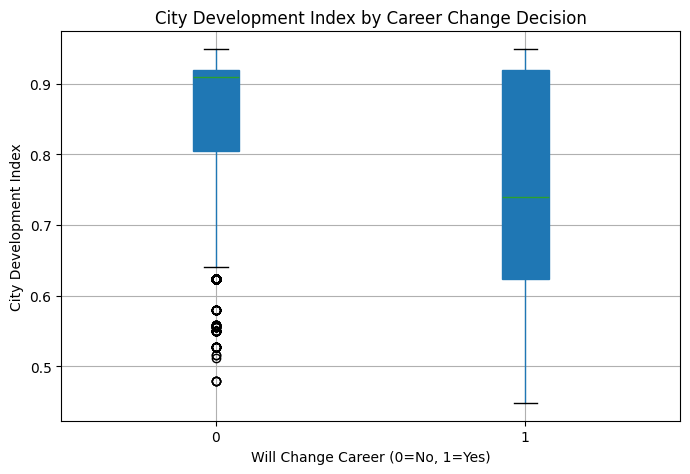

In [ ]:
# --- City Development Index vs Career Change (Boxplot) ---
plt.figure(figsize=(7, 5))
df.boxplot(column='city_development_index', by='will_change_career',
           patch_artist=True, figsize=(7, 5))
plt.title('City Development Index by Career Change Decision')
plt.suptitle('')
plt.xlabel('Will Change Career (0=No, 1=Yes)')
plt.ylabel('City Development Index')
plt.tight_layout()
plt.show()

---
## Section 3: Dataset Pre-processing

### 3.1 Fault: Null / Missing Values

Missing Values per Column:
                     Missing Count  Missing %
gender                        1113      22.26
enrolled_university            107       2.14
education_level                118       2.36
major_discipline               724      14.48
experience                      11       0.22
company_size                  1571      31.42
company_type                  1621      32.42
last_new_job                   104       2.08


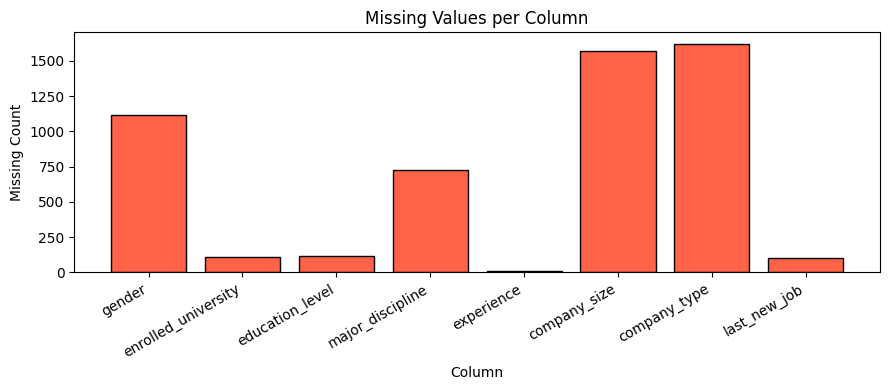

In [ ]:
print("Missing Values per Column:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

# Visualize missing values
plt.figure(figsize=(9, 4))
missing_only = missing[missing > 0]
plt.bar(missing_only.index, missing_only.values, color='tomato', edgecolor='black')
plt.title('Missing Values per Column')
plt.xlabel('Column')
plt.ylabel('Missing Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df_clean = df.copy()

# Drop enrollee_id — it's just an identifier, not a feature
df_clean.drop(columns=['enrollee_id', 'city'], inplace=True)
print("Dropped: enrollee_id (identifier), city (too many unique values, CDI already captures city info)")

# Impute missing values with mode (most frequent value)
cols_to_impute = ['gender', 'enrolled_university', 'education_level',
                  'major_discipline', 'experience', 'company_size',
                  'company_type', 'last_new_job']

for col in cols_to_impute:
    mode_val = df_clean[col].mode()[0]
    df_clean[col].fillna(mode_val, inplace=True)
    print(f"  Imputed '{col}' with mode: '{mode_val}'")

print()
print("Missing values after imputation:")
print(df_clean.isnull().sum())

Dropped: enrollee_id (identifier), city (too many unique values, CDI already captures city info)
  Imputed 'gender' with mode: 'Male'
  Imputed 'enrolled_university' with mode: 'no_enrollment'
  Imputed 'education_level' with mode: 'Graduate'
  Imputed 'major_discipline' with mode: 'STEM'
  Imputed 'experience' with mode: '>20'
  Imputed 'company_size' with mode: '50-99'
  Imputed 'company_type' with mode: 'Pvt Ltd'
  Imputed 'last_new_job' with mode: '1'

Missing values after imputation:
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
will_change_career        0
dtype: int64


In [ ]:
df_encoded = df_clean.copy()
le = LabelEncoder()

# --- Label Encoding for ordinal/binary features ---

# gender
df_encoded['gender'] = le.fit_transform(df_encoded['gender'])
print("gender encoded:", dict(zip(le.classes_, le.transform(le.classes_))))

# relevent_experience
df_encoded['relevent_experience'] = df_encoded['relevent_experience'].map(
    {'No relevent experience': 0, 'Has relevent experience': 1}
)
print("relevent_experience: No=0, Has=1")

# education_level (ordinal)
edu_order = {'Primary School': 0, 'High School': 1, 'Graduate': 2, 'Masters': 3, 'Phd': 4}
df_encoded['education_level'] = df_encoded['education_level'].map(edu_order)
print("education_level (ordinal):", edu_order)

# experience — fix '>20' and '<1', then convert to int
df_encoded['experience'] = df_encoded['experience'].replace('>20', '21').replace('<1', '0')
df_encoded['experience'] = df_encoded['experience'].astype(int)
print("experience: converted to integer (>20 -> 21, <1 -> 0)")

# company_size (ordinal)
size_order = {'<10': 0, 'Oct-49': 1, '50-99': 2, '100-500': 3,
              '500-999': 4, '1000-4999': 5, '5000-9999': 6, '10000+': 7}
df_encoded['company_size'] = df_encoded['company_size'].map(size_order)
print("company_size (ordinal):", size_order)

# last_new_job (ordinal)
df_encoded['last_new_job'] = df_encoded['last_new_job'].replace('>4', '5')
df_encoded['last_new_job'] = df_encoded['last_new_job'].astype(int)
print("last_new_job: converted to integer (>4 -> 5)")

print()

# --- One-Hot Encoding for nominal features ---
nominal_cols = ['enrolled_university', 'major_discipline', 'company_type']
df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, drop_first=True)
print("One-Hot Encoded:", nominal_cols)
print()
print("Final shape after encoding:", df_encoded.shape)
print("Columns:", df_encoded.columns.tolist())

gender encoded: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
relevent_experience: No=0, Has=1
education_level (ordinal): {'Primary School': 0, 'High School': 1, 'Graduate': 2, 'Masters': 3, 'Phd': 4}
experience: converted to integer (>20 -> 21, <1 -> 0)
company_size (ordinal): {'<10': 0, 'Oct-49': 1, '50-99': 2, '100-500': 3, '500-999': 4, '1000-4999': 5, '5000-9999': 6, '10000+': 7}
last_new_job: converted to integer (>4 -> 5)

One-Hot Encoded: ['enrolled_university', 'major_discipline', 'company_type']

Final shape after encoding: (5000, 21)
Columns: ['city_development_index', 'gender', 'relevent_experience', 'education_level', 'experience', 'company_size', 'last_new_job', 'training_hours', 'will_change_career', 'enrolled_university_Part time course', 'enrolled_university_no_enrollment', 'major_discipline_Business Degree', 'major_discipline_Humanities', 'major_discipline_No Major', 'major_discipline_Other', 'major_discipline_STEM', 'company_type_Funded Startup',

### 2.4 Correlation Heatmap (After Encoding)

We apply the correlation heatmap after encoding so all features are numerical.

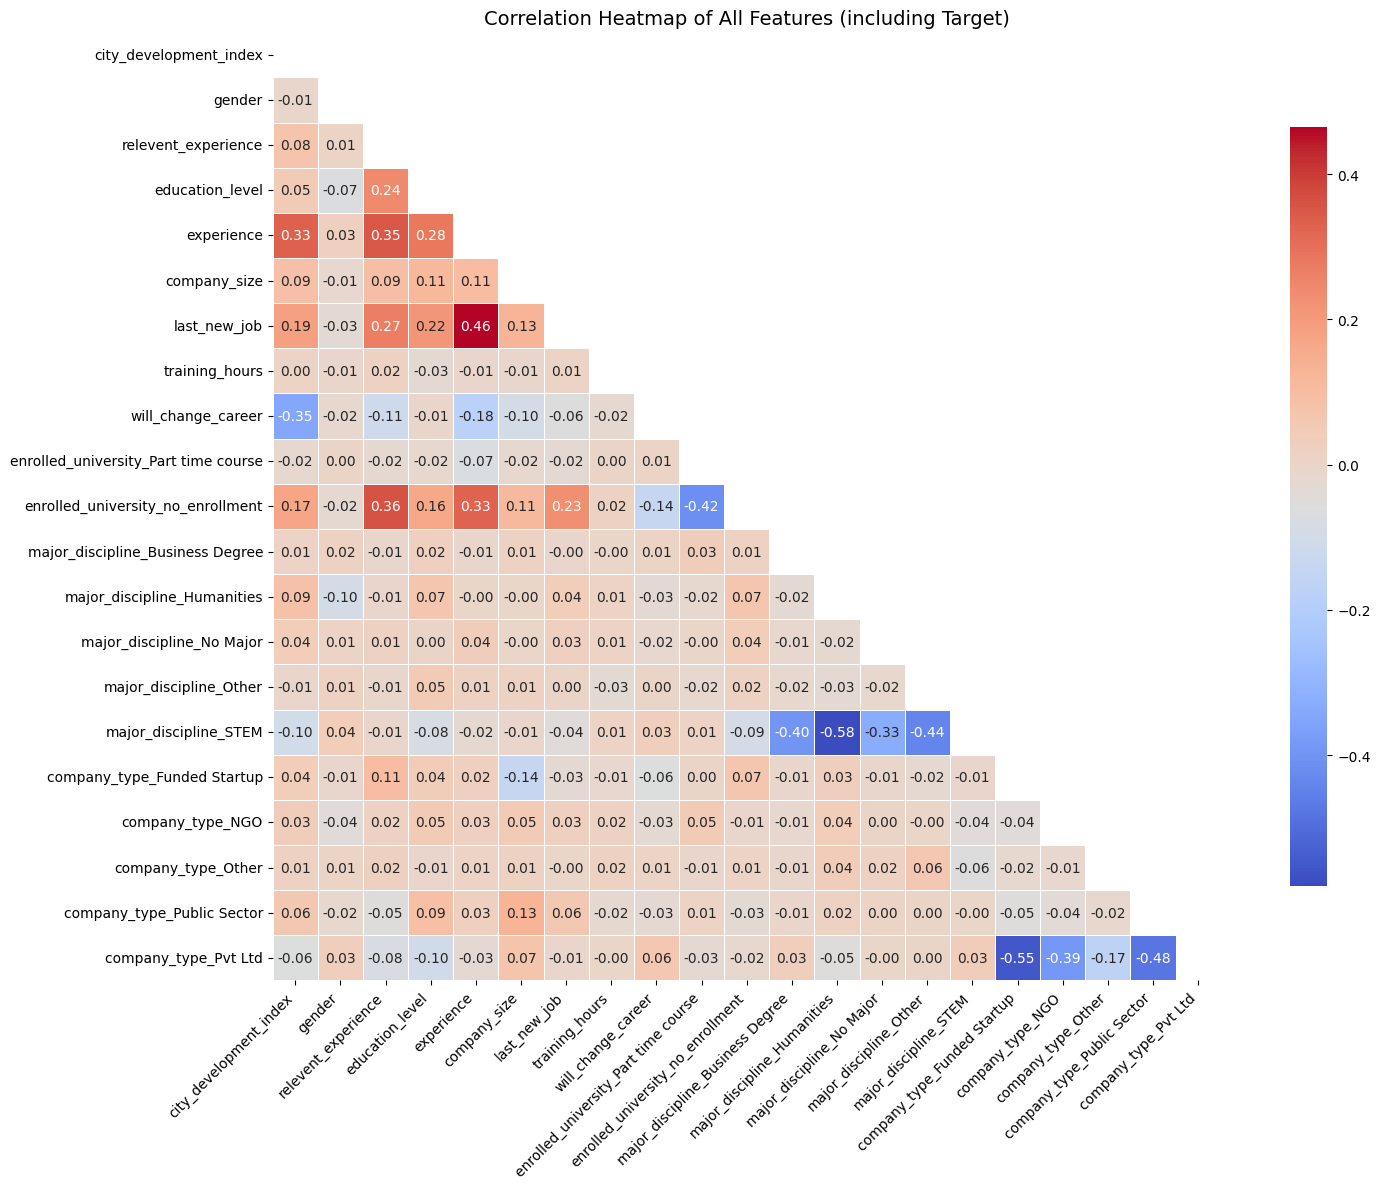


Top features correlated with target (will_change_career):
city_development_index               0.346808
experience                           0.176754
enrolled_university_no_enrollment    0.140237
relevent_experience                  0.112887
company_size                         0.097056
company_type_Pvt Ltd                 0.064673
company_type_Funded Startup          0.059849
last_new_job                         0.055095
Name: will_change_career, dtype: float64

Observation: city_development_index and experience show the highest correlation with the target.


In [ ]:
plt.figure(figsize=(16, 12))
corr_matrix = df_encoded.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap of All Features (including Target)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print()
print("Top features correlated with target (will_change_career):")
target_corr = corr_matrix['will_change_career'].drop('will_change_career').abs().sort_values(ascending=False)
print(target_corr.head(8))
print()
print("Observation: city_development_index and experience show the highest correlation with the target.")

---
## Section 4: Dataset Splitting

In [ ]:
# Separate features and target
X = df_encoded.drop(columns=['will_change_career'])
y = df_encoded['will_change_career']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print()

# Stratified Train-Test Split (80% train, 20% test)
# We use STRATIFIED splitting because the dataset is imbalanced
# Stratified ensures both classes are proportionally represented in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set   : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set       : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print()
print("Class distribution in Training set:")
print(y_train.value_counts())
print()
print("Class distribution in Test set:")
print(y_test.value_counts())

# Apply Feature Scaling (fit on train only, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print()
print("Feature scaling applied (StandardScaler).")
print("Scaler fitted on training data only to prevent data leakage.")

Features shape : (5000, 20)
Target shape   : (5000,)

Training set   : 4000 samples (80%)
Test set       : 1000 samples (20%)

Class distribution in Training set:
will_change_career
0    2990
1    1010
Name: count, dtype: int64

Class distribution in Test set:
will_change_career
0    748
1    252
Name: count, dtype: int64

Feature scaling applied (StandardScaler).
Scaler fitted on training data only to prevent data leakage.


---
## Section 5: Model Training & Testing

### Helper Function for Evaluation

In [ ]:
# Dictionary to store all model results for comparison
results = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, is_neural_net=False, y_prob=None):
    """Train, evaluate, and store results for a model."""
    if not is_neural_net:
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        y_pred = (y_prob >= 0.5).astype(int)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob)

    results[name] = {
        'Accuracy'  : acc,
        'Precision' : prec,
        'Recall'    : rec,
        'AUC'       : auc,
        'y_pred'    : y_pred,
        'y_prob'    : y_prob
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  AUC Score : {auc:.4f}")
    print()
    print("  Classification Report:")
    print(classification_report(y_te, y_pred, target_names=['No Change', 'Change']))

    # Confusion Matrix
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Change', 'Change'],
                yticklabels=['No Change', 'Change'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return model

### 5.1 Logistic Regression


  Logistic Regression
  Accuracy  : 0.7630
  Precision : 0.5556
  Recall    : 0.2976
  AUC Score : 0.7159

  Classification Report:
              precision    recall  f1-score   support

   No Change       0.80      0.92      0.85       748
      Change       0.56      0.30      0.39       252

    accuracy                           0.76      1000
   macro avg       0.68      0.61      0.62      1000
weighted avg       0.73      0.76      0.74      1000



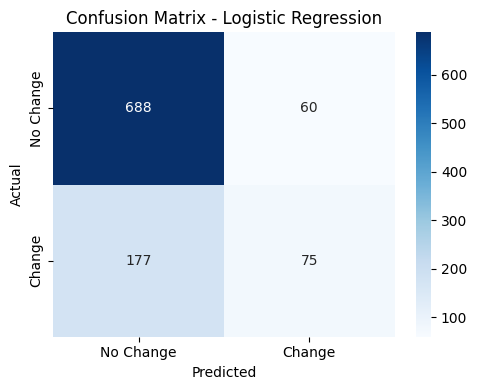

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
evaluate_model('Logistic Regression', lr_model,
               X_train_scaled, X_test_scaled, y_train, y_test)

### 5.2 K-Nearest Neighbors (KNN)

Best K = 17 with accuracy = 0.7710


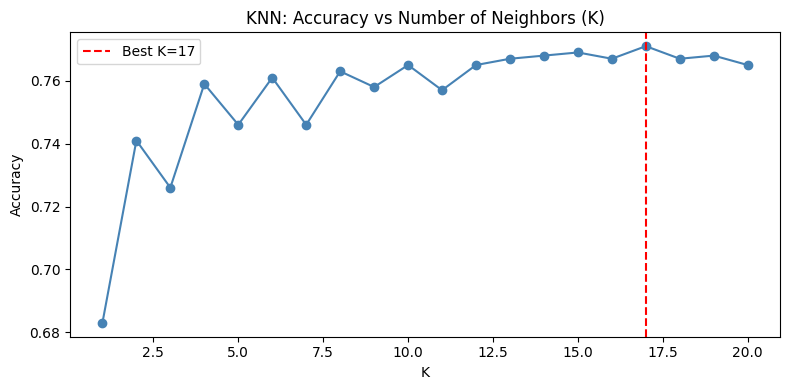

In [ ]:
# Find optimal K using elbow method
k_range = range(1, 21)
k_accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    k_accuracies.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

best_k = k_range[np.argmax(k_accuracies)]
print(f"Best K = {best_k} with accuracy = {max(k_accuracies):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(k_range, k_accuracies, marker='o', color='steelblue')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.title('KNN: Accuracy vs Number of Neighbors (K)')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


  KNN
  Accuracy  : 0.7710
  Precision : 0.5706
  Recall    : 0.3690
  AUC Score : 0.7087

  Classification Report:
              precision    recall  f1-score   support

   No Change       0.81      0.91      0.86       748
      Change       0.57      0.37      0.45       252

    accuracy                           0.77      1000
   macro avg       0.69      0.64      0.65      1000
weighted avg       0.75      0.77      0.75      1000



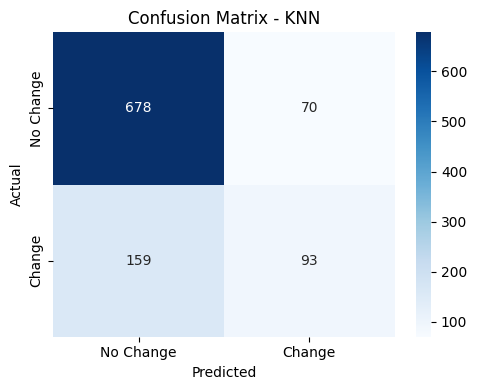

KNeighborsClassifier(n_neighbors=17)

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)
evaluate_model('KNN', knn_model,
               X_train_scaled, X_test_scaled, y_train, y_test)

### 5.3 Decision Tree


  Decision Tree
  Accuracy  : 0.7800
  Precision : 0.5909
  Recall    : 0.4127
  AUC Score : 0.7567

  Classification Report:
              precision    recall  f1-score   support

   No Change       0.82      0.90      0.86       748
      Change       0.59      0.41      0.49       252

    accuracy                           0.78      1000
   macro avg       0.71      0.66      0.67      1000
weighted avg       0.76      0.78      0.77      1000



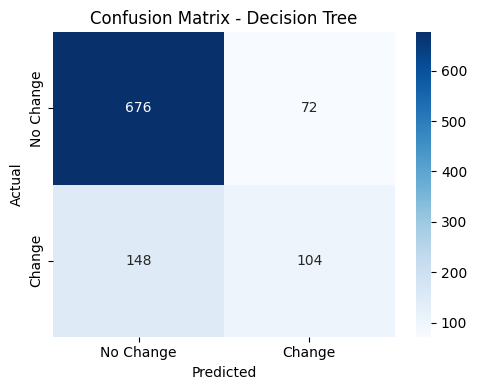

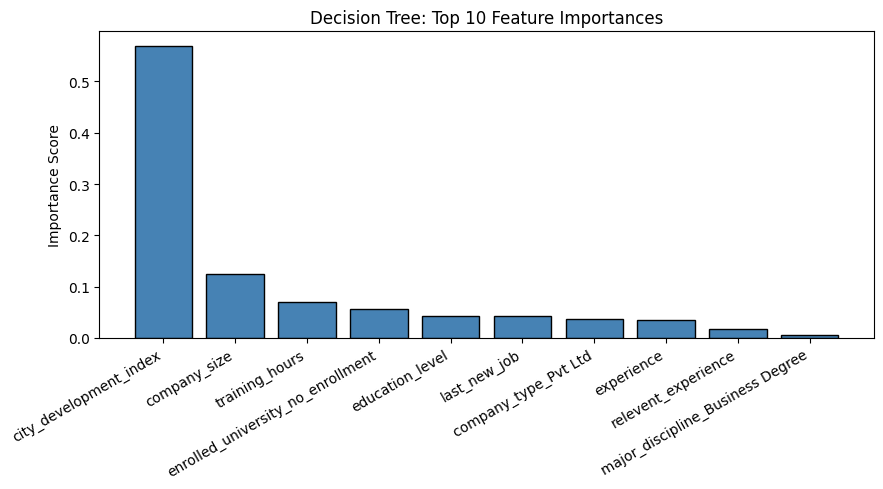

In [ ]:
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
evaluate_model('Decision Tree', dt_model,
               X_train_scaled, X_test_scaled, y_train, y_test)

# Feature importance
feature_names = X.columns.tolist()
importances = dt_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(9, 5))
plt.bar(range(10), importances[indices], color='steelblue', edgecolor='black')
plt.xticks(range(10), [feature_names[i] for i in indices], rotation=30, ha='right')
plt.title('Decision Tree: Top 10 Feature Importances')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

### 5.4 Naive Bayes


  Naive Bayes
  Accuracy  : 0.7060
  Precision : 0.4403
  Recall    : 0.6151
  AUC Score : 0.6839

  Classification Report:
              precision    recall  f1-score   support

   No Change       0.85      0.74      0.79       748
      Change       0.44      0.62      0.51       252

    accuracy                           0.71      1000
   macro avg       0.65      0.68      0.65      1000
weighted avg       0.75      0.71      0.72      1000



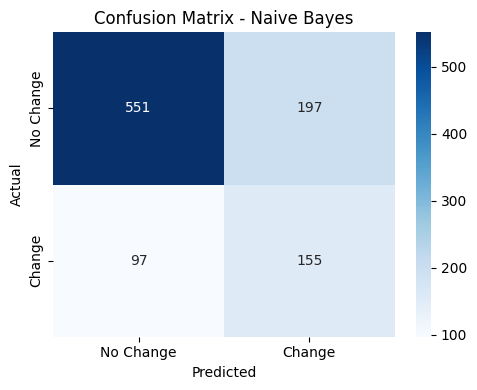

GaussianNB()

In [ ]:
nb_model = GaussianNB()
evaluate_model('Naive Bayes', nb_model,
               X_train_scaled, X_test_scaled, y_train, y_test)

### 5.5 Neural Network (TensorFlow / Keras)

In [ ]:
tf.random.set_seed(42)

nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')   # sigmoid for binary classification
])

nn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,825 (54.00 KB)

 Trainable params: 13,441 (52.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6218 - loss: 0.6810 - val_accuracy: 0.7883 - val_loss: 0.5277
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7491 - loss: 0.5362 - val_accuracy: 0.7883 - val_loss: 0.4818
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7612 - loss: 0.5264 - val_accuracy: 0.7917 - val_loss: 0.4678
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7700 - loss: 0.5104 - val_accuracy: 0.7867 - val_loss: 0.4545
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7726 - loss: 0.5050 - val_accuracy: 0.7900 - val_loss: 0.4527
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7718 - loss: 0.4975 - val_accuracy: 0.7833 - val_loss: 0.4519
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7741 - loss: 0.4971 - val_accuracy: 0.7850 - val_loss: 0.4507
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7709 - loss: 0.4891 - val_accuracy: 0.7850 - v

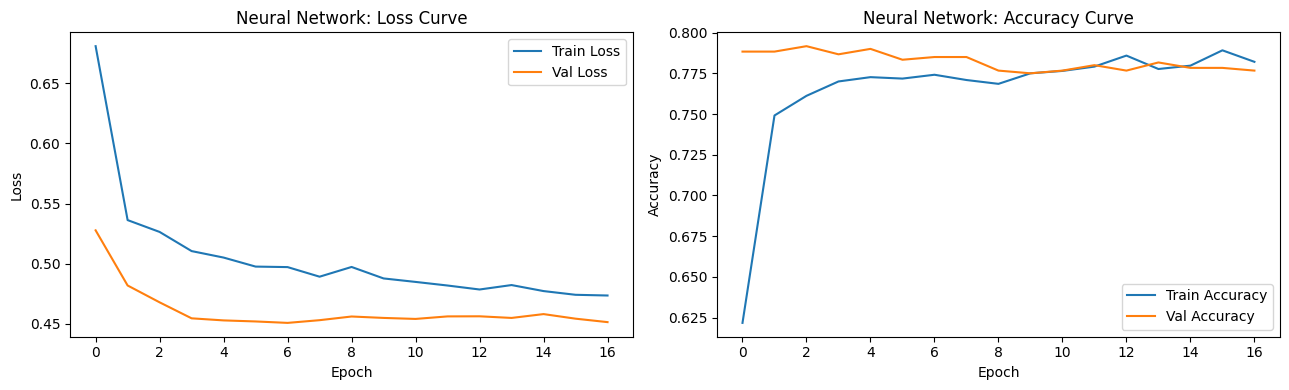

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Neural Network: Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Neural Network: Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

  Neural Network
  Accuracy  : 0.7750
  Precision : 0.6080
  Recall    : 0.3016
  AUC Score : 0.7246

  Classification Report:
              precision    recall  f1-score   support

   No Change       0.80      0.93      0.86       748
      Change       0.61      0.30      0.40       252

    accuracy                           0.78      1000
   macro avg       0.70      0.62      0.63      1000
weighted avg       0.75      0.78      0.75      1000



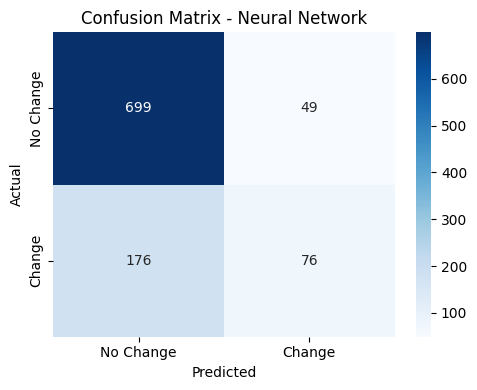

<Sequential name=sequential, built=True>

In [ ]:
# Evaluate Neural Network
nn_prob = nn_model.predict(X_test_scaled).flatten()
evaluate_model('Neural Network', nn_model,
               X_train_scaled, X_test_scaled, y_train, y_test,
               is_neural_net=True, y_prob=nn_prob)

### 5.6 KMeans Clustering (Unsupervised)

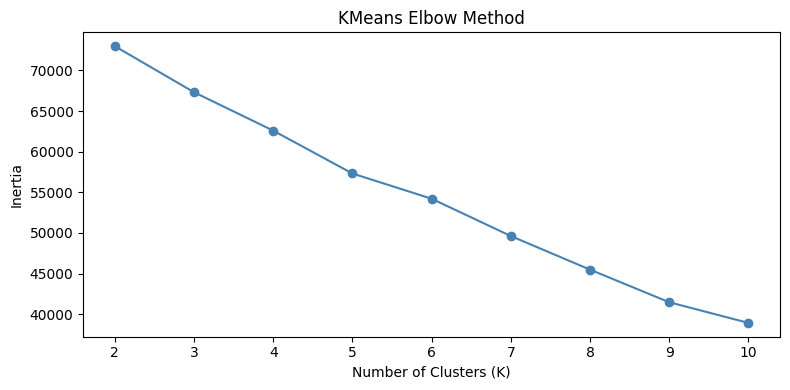

In [ ]:
# Elbow method to find optimal number of clusters
inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', color='steelblue')
plt.title('KMeans Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

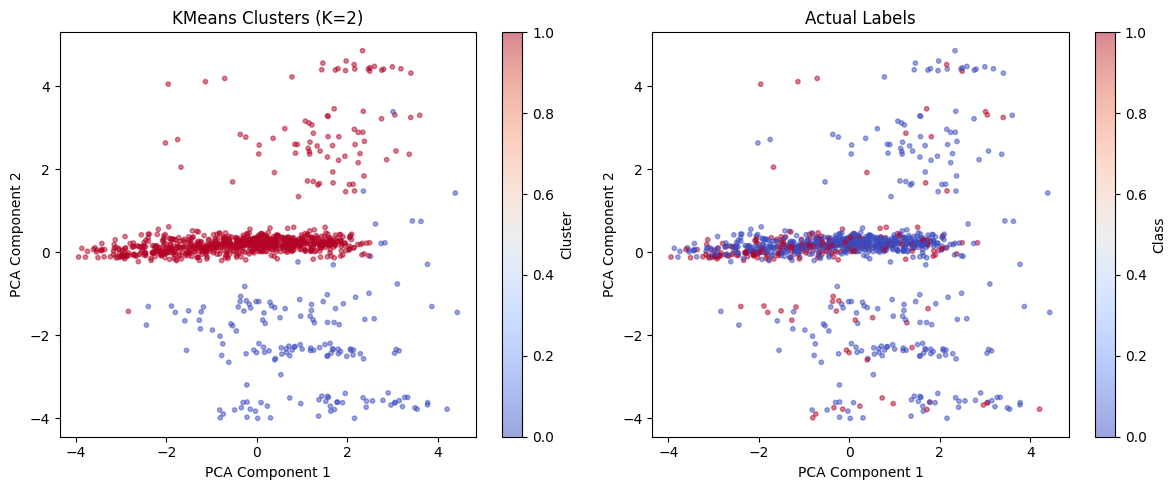

KMeans Cluster Distribution:
  Cluster 0: 164 samples
  Cluster 1: 836 samples


In [ ]:
# Apply KMeans with K=2 (matches our 2 target classes)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)
cluster_labels = kmeans.predict(X_test_scaled)

# Visualize clusters using first 2 principal components (PCA for 2D)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)

plt.figure(figsize=(12, 5))

# KMeans Clusters
plt.subplot(1, 2, 1)
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1],
            c=cluster_labels, cmap='coolwarm', alpha=0.5, s=10)
plt.title('KMeans Clusters (K=2)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')

# Actual Labels
plt.subplot(1, 2, 2)
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1],
            c=y_test.values, cmap='coolwarm', alpha=0.5, s=10)
plt.title('Actual Labels')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Class')

plt.tight_layout()
plt.show()

print("KMeans Cluster Distribution:")
unique, counts = np.unique(cluster_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} samples")

---
## Section 6: Model Comparison Analysis

In [ ]:
# Build results summary table
summary = pd.DataFrame({
    'Model'     : list(results.keys()),
    'Accuracy'  : [results[m]['Accuracy']  for m in results],
    'Precision' : [results[m]['Precision'] for m in results],
    'Recall'    : [results[m]['Recall']    for m in results],
    'AUC Score' : [results[m]['AUC']       for m in results],
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("Model Performance Summary:")
print(summary.to_string(index=False))

Model Performance Summary:
              Model  Accuracy  Precision   Recall  AUC Score
      Decision Tree     0.780   0.590909 0.412698   0.756714
     Neural Network     0.775   0.608000 0.301587   0.724570
                KNN     0.771   0.570552 0.369048   0.708707
Logistic Regression     0.763   0.555556 0.297619   0.715867
        Naive Bayes     0.706   0.440341 0.615079   0.683935


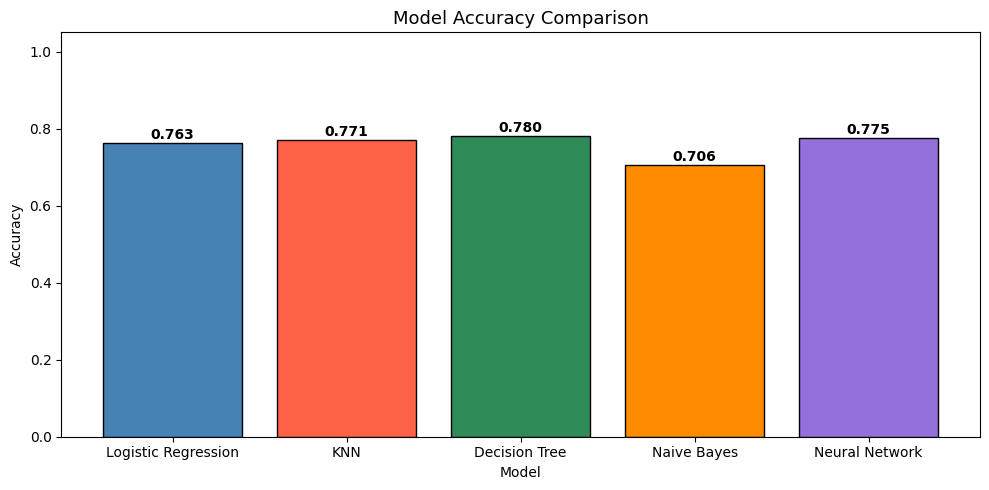

In [ ]:
# --- Bar Chart: Accuracy Comparison ---
model_names = list(results.keys())
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']

plt.figure(figsize=(10, 5))
bars = plt.bar(model_names,
               [results[m]['Accuracy'] for m in model_names],
               color=colors, edgecolor='black')
for bar, m in zip(bars, model_names):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003,
             f"{results[m]['Accuracy']:.3f}",
             ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('Model Accuracy Comparison', fontsize=13)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

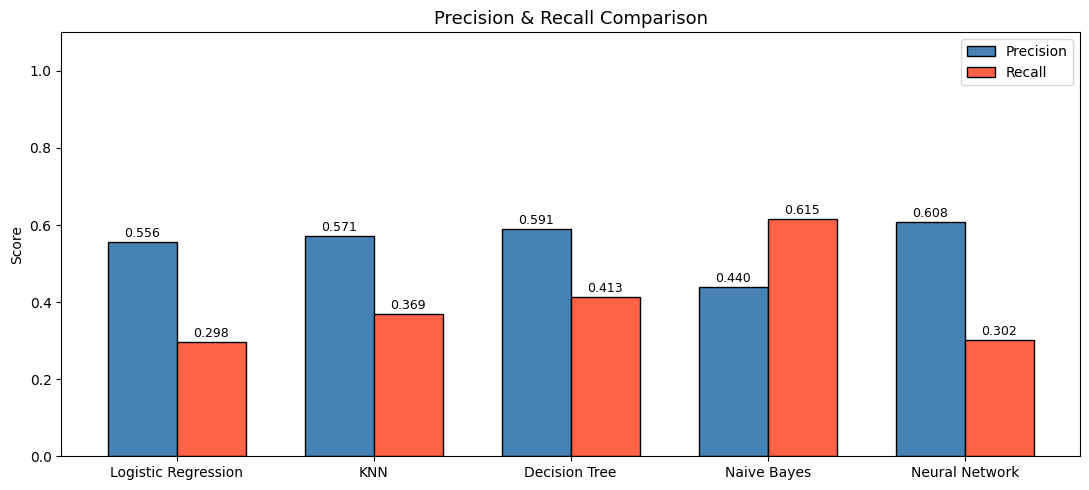

In [ ]:
# --- Bar Chart: Precision & Recall Comparison ---
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, [results[m]['Precision'] for m in model_names],
               width, label='Precision', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, [results[m]['Recall'] for m in model_names],
               width, label='Recall', color='tomato', edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)

ax.set_title('Precision & Recall Comparison', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

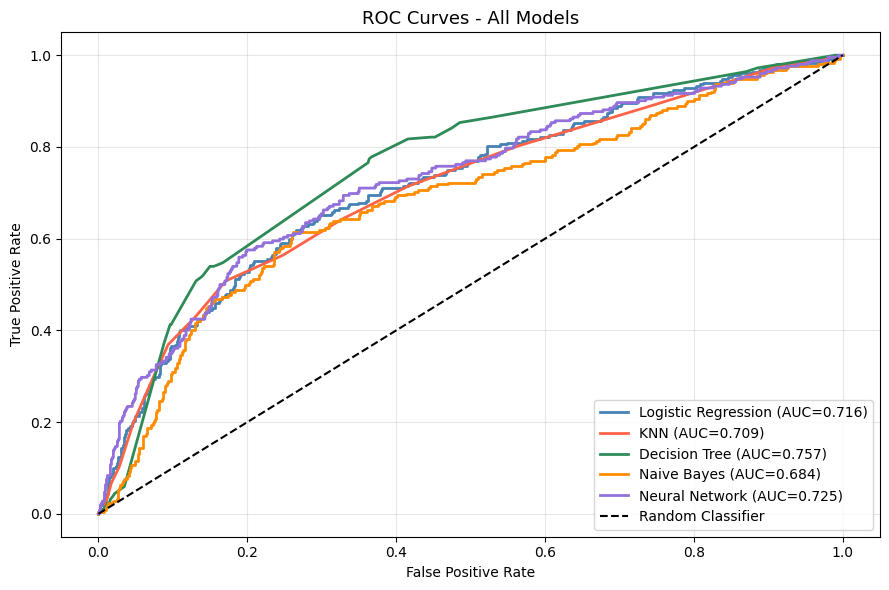

In [ ]:
# --- ROC Curves for all models ---
plt.figure(figsize=(9, 6))

for i, (m_name, color) in enumerate(zip(model_names, colors)):
    fpr, tpr, _ = roc_curve(y_test, results[m_name]['y_prob'])
    auc_val = results[m_name]['AUC']
    plt.plot(fpr, tpr, label=f"{m_name} (AUC={auc_val:.3f})", color=color, lw=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title('ROC Curves - All Models', fontsize=13)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

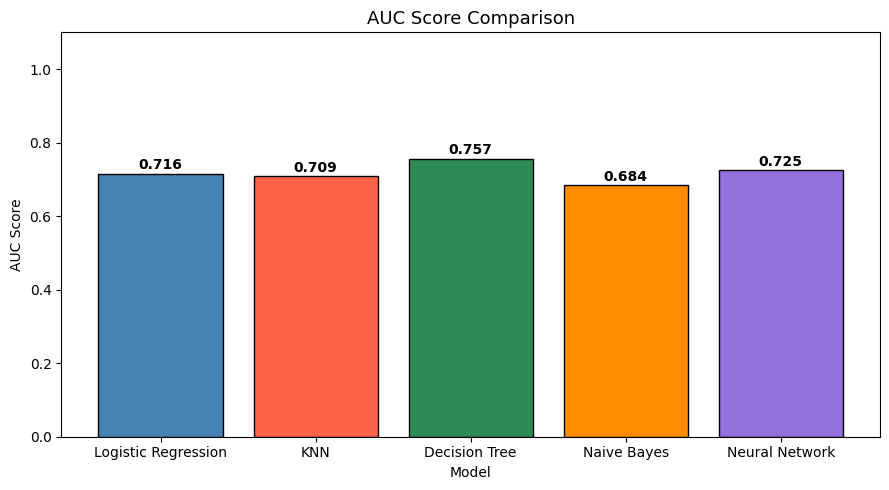

In [ ]:
# --- AUC Score Comparison ---
plt.figure(figsize=(9, 5))
bars = plt.bar(model_names,
               [results[m]['AUC'] for m in model_names],
               color=colors, edgecolor='black')
for bar, m in zip(bars, model_names):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003,
             f"{results[m]['AUC']:.3f}",
             ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('AUC Score Comparison', fontsize=13)
plt.xlabel('Model')
plt.ylabel('AUC Score')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

---
## Section 7: Conclusion

### Summary of Results

In [ ]:
print("=" * 60)
print("  FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 60)
print(summary.to_string(index=False))
best_model = summary.iloc[0]['Model']
best_acc   = summary.iloc[0]['Accuracy']
print()
print(f"  Best Performing Model : {best_model}")
print(f"  Best Accuracy         : {best_acc:.4f}")
print("=" * 60)

  FINAL MODEL PERFORMANCE SUMMARY
              Model  Accuracy  Precision   Recall  AUC Score
      Decision Tree     0.780   0.590909 0.412698   0.756714
     Neural Network     0.775   0.608000 0.301587   0.724570
                KNN     0.771   0.570552 0.369048   0.708707
Logistic Regression     0.763   0.555556 0.297619   0.715867
        Naive Bayes     0.706   0.440341 0.615079   0.683935

  Best Performing Model : Decision Tree
  Best Accuracy         : 0.7800
